# Data Understanding (EDA)
Here, we are going to start understanding our data. We will charge the data and see what information we can extract from it.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
plt.style.use('ggplot')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (12, 6)

print("📥 1. Charging Rossmann data...")
df_train = pd.read_csv('../data/train.csv', parse_dates=['Date'], low_memory=False)
df_store = pd.read_csv('../data/store.csv')

print(f"Rows in sales history (train): {df_train.shape[0]:,}")
print(f"Unique stores (store): {df_store.shape[0]:,}")

display(df_train.head())

📥 1. Charging Rossmann data...
Rows in sales history (train): 1,017,209
Unique stores (store): 1,115


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
display(df_store.head())

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


As we can see, we've got 2 different data tables. One is about the daily sabes by store (train) and the other is about the attributes of each store (store). They are connected by the columns `Store`, that are the same in both tables.

Now, we will inspect more deeply our data.

### Daily Sales

In [8]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


Which is the meaning of each feature:

* `Store`: a unique Id for each store.

* `DayOfWeek`: indicates the day of the week (1 = Monday, 7 = Sunday).

* `Date`: the date of the historical record.

* `Sales`: the turnover for any given day (this is our target variable).

* `Customers`: the number of customers on a given day. 
    > *(Note: Data Leakage risk - we cannot use this to predict future sales).*

* `Open`: an indicator for whether the store was open: 0 = closed, 1 = open.

* `Promo`: indicates whether a store is running a promotion on that day.

* `StateHoliday`: indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays (a = public holiday, b = Easter holiday, c = Christmas, 0 = None).

* `SchoolHoliday`: indicates if the (Store, Date) was affected by the closure of public schools.



***Important NOTES***
* Customers won't be a predictor because we do not know how many customers we will have tomorrow.

* Open: when the shop is closed, we will automatically predict 0 sales.

In [9]:
df_open = df_train[(df_train["Open"]==1) & (df_train["Sales"]>0)].drop("Open", axis=1)
df_open.shape[0]

844338

We put the condition of `Sales` because if a store opens, it should recieve at least 1 sale. If not, we will say it is an informatic error and we will not feed our model with days being open and not selling because it will lower its predictions.

We drop the `Open` column because it is not relevant anymore.

In [10]:
df_open.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1


In [11]:
df_open.describe()

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729703,6955.959134,762.777166,0.446356,0.193578
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,0.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.000000,1.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.497114,0.395102


### Store Attributes

In [12]:
df_store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


Which is the meaning of each feature:

* `Store`: a unique Id for each store (Used to join with train data).

* `StoreType`: differentiates between 4 different store models: a, b, c, d.

* `Assortment`: describes an assortment level: a = basic, b = extra, c = extended.

* `CompetitionDistance`: distance in meters to the nearest competitor store.

* `CompetitionOpenSinceMonth`: gives the approximate month of the time the nearest competitor was opened.

* `CompetitionOpenSinceYear`: gives the approximate year of the time the nearest competitor was opened.

* `Promo2`: Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating.

* `Promo2SinceWeek`: describes the calendar week when the store started participating in Promo2.

* `Promo2SinceYear`: describes the year when the store started participating in Promo2.

* `PromoInterval`: describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in those specific months for that store.

In [13]:
df_store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [14]:
df_store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


## EDA (Exploratory Data Analysis)

### Data Validation (Preliminary Check)

1. Detect Missing Values
2. Detect Inconsistencies
3. Detect Duplicates

### Missing Values

In [15]:
df_open.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

There are not missings in the daily sales data.

In [16]:
store_na = df_store.isna().mean().sort_values(ascending=False)
store_na[store_na>0]

Promo2SinceWeek              0.487892
Promo2SinceYear              0.487892
PromoInterval                0.487892
CompetitionOpenSinceMonth    0.317489
CompetitionOpenSinceYear     0.317489
CompetitionDistance          0.002691
dtype: float64

Basically, if a Store did not start Promo 2 (They have a 0 in `Promo2` column), they will have a missing value in those first 3 missing value columns (`Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval`).

The other missings (`CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`) are not missing because there is not competence (`CompetitionDistance` is not null), but because one of these reasons:

* Competitor is very old (Most probable): they do not know the opening date of a store that is in the city since 1980 for example.

* Human Error: a human that is in charge of typing this data manually does not know the exact date and leave it as missing.

* Business Evolution: imagine a store that was not competence previously starts to sell products that compete with you. Maybe the team of Rossmann left is as missing.

<br>

**How would we treat those missings?**

Measuring the distance to a competitor in early years was pretty easy. The manager opened Google Maps, wrote the direction of the competitor and saw the distance there. It cost 1 minute.

However, if that competitor was a local pharmacy and it was there since 1980... How does the manager discover the year of opening? They left is as missing value.

But imagine that new Data teams in Rossmann started working on gathering this data because measuring the impact of a competitor's opening is pretty informative. They updated the Software and started to fill those values for new competitors and the old ones remained the same (nulls).

If we take a look at the distribution of `CompetitionOpenSinceYear`, we can clearly see this:

In [17]:
df_store["CompetitionOpenSinceYear"].value_counts().sort_index()

CompetitionOpenSinceYear
1900.0     1
1961.0     1
1990.0     5
1994.0     2
1995.0     2
1998.0     1
1999.0     8
2000.0    10
2001.0    16
2002.0    27
2003.0    19
2004.0    22
2005.0    62
2006.0    47
2007.0    48
2008.0    54
2009.0    54
2010.0    55
2011.0    54
2012.0    82
2013.0    83
2014.0    70
2015.0    38
Name: count, dtype: int64

Missing values in `CompetitionOpenSinceMonth` and `CompetitionOpenSinceYear` should be imputed with January 2013 (the start of our historical dataset). This establishes a "Day Zero" baseline, ensuring the model assumes the competitor's market impact was already fully absorbed into the store's initial sales figures.

In [18]:
df_store[df_store["CompetitionDistance"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


The most plausible explanation here is that these stores do not have any competitor close to them. So, we will impute these missings with the maximum distance in our dataset, ensuring that our model will learn that these stores have the most far competition.

### Inconsistencies

In [19]:
df_open.describe()

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729703,6955.959134,762.777166,0.446356,0.193578
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,0.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.000000,1.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.497114,0.395102


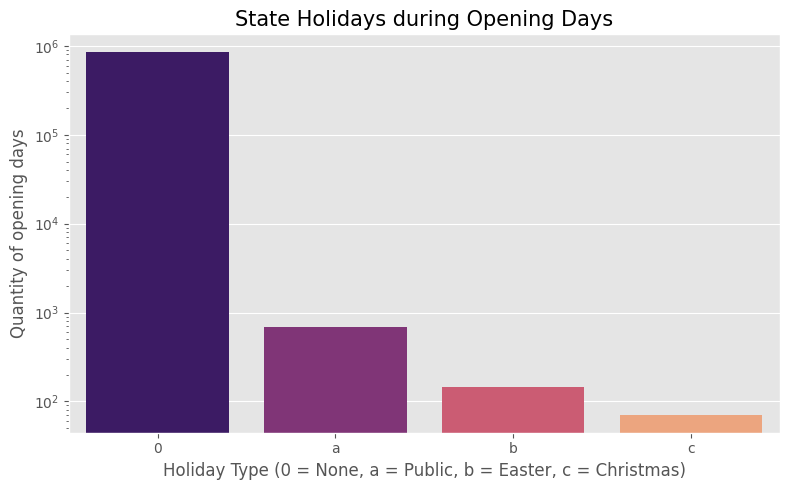

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_open, x='StateHoliday', palette='magma', hue='StateHoliday',
              order=df_open['StateHoliday'].value_counts().index)

plt.title('State Holidays during Opening Days', fontsize=15)
plt.xlabel('Holiday Type (0 = None, a = Public, b = Easter, c = Christmas)')
plt.ylabel('Quantity of opening days')
# 0 would be enourmus
plt.yscale('log') 
plt.tight_layout()
plt.show()

We see good data here, not inconsistencies.

In [21]:
df_store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


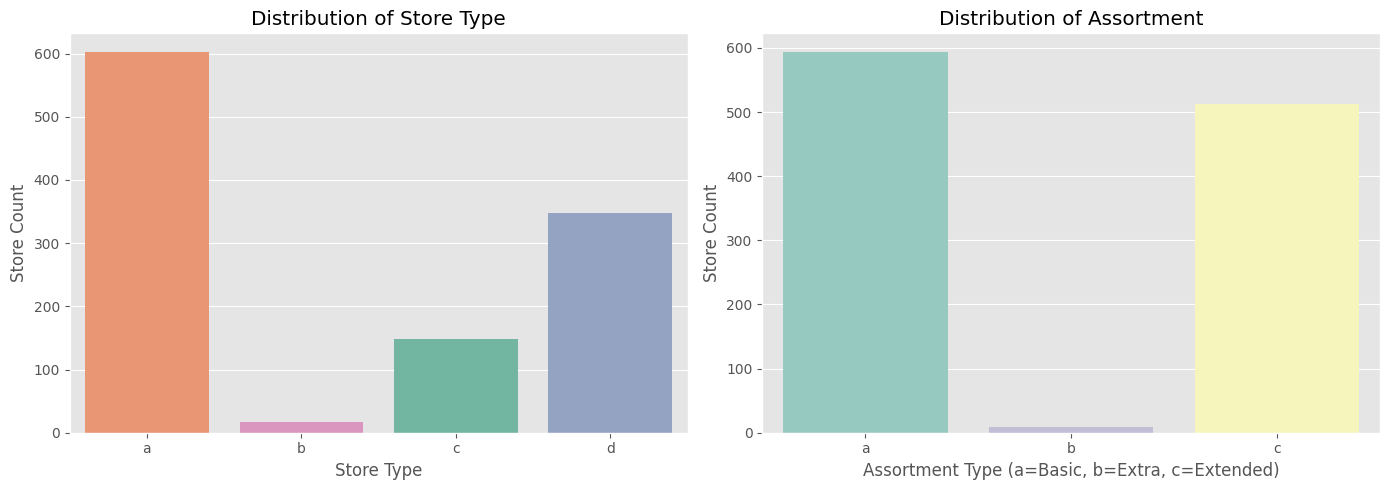

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Tipo de Tienda (StoreType)
sns.countplot(data=df_store, x='StoreType', palette='Set2', hue='StoreType',
              order=['a', 'b', 'c', 'd'], ax=axes[0])
axes[0].set_title('Distribution of Store Type')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Store Count')

# Gráfico B: Nivel de Surtido (Assortment)
# a = básico, b = extra, c = extendido
sns.countplot(data=df_store, x='Assortment', palette='Set3', hue='Assortment',
              order=['a', 'b', 'c'], ax=axes[1])
axes[1].set_title('Distribution of Assortment')
axes[1].set_xlabel('Assortment Type (a=Basic, b=Extra, c=Extended)')
axes[1].set_ylabel('Store Count')

plt.tight_layout()
plt.show()

Numerical data is good, there are not inconsistencies, and categorical data is also well defined, with all data gathered correctly.

### Duplicates

In [23]:
print(f"There are these duplicated days sales: {int(df_open.duplicated().any())}")
print(f"There are these duplicated stores: {int(df_store.duplicated().any())}")

There are these duplicated days sales: 0
There are these duplicated stores: 0


## Key questions to resolve in EDA

* Distribution of Sales? What is a normal or rare day?

* Is launching a promo related to selling more?

* How are holidays related to sales?

* Store Type or Assorment level influences sales?

* Are stores with closer competence selling less than those with no competence near them?

* Are stores in Promo 2 selling more than those who are not in the program?

* How do sales vary across time? Which days of the week and months are the most profitable? Is there a clear yearly seasonality?

* Store behavior during Sundays: Since most stores are closed on Sundays, do the few stores that remain open experience a massive spike in sales (monopoly effect)?


To solve these questions, we would have to merge the data.

In [24]:
df_master = df_open.merge(df_store, how="inner", left_on="Store", right_on="Store").sort_values(by=["Date", "Store"]).set_index("Date")
df_master.head()

,Store,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Date,,,,,,,,,,,,,,,,
2013-01-01,85,2,4220,619,0,a,1,b,a,1870.0,10.0,2011.0,0,NaN,NaN,NaN
2013-01-01,259,2,6851,1444,0,a,1,b,b,210.0,NaN,NaN,0,NaN,NaN,NaN
2013-01-01,262,2,17267,2875,0,a,1,b,a,1180.0,5.0,2013.0,0,NaN,NaN,NaN
2013-01-01,274,2,3102,729,0,a,1,b,b,3640.0,NaN,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct"
2013-01-01,335,2,2401,482,0,a,1,b,a,90.0,NaN,NaN,1,31.0,2013.0,"Jan,Apr,Jul,Oct"


### Univariate Analysis

UNIVARIATE ANALYSIS: The Target Variable (Sales)


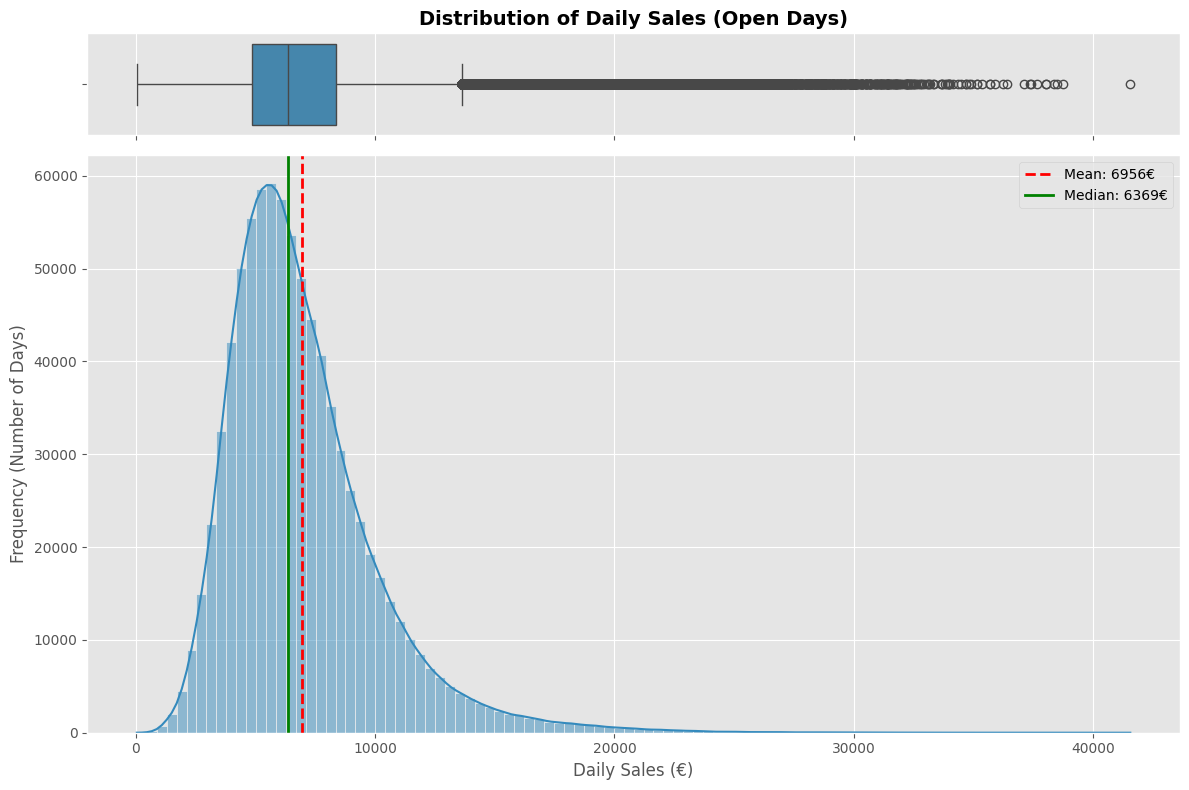

,count,mean,std,min,25%,50%,75%,max
Sales,844338.0,6955.959134,3103.815515,46.0,4859.0,6369.0,8360.0,41551.0


In [25]:
print("UNIVARIATE ANALYSIS: The Target Variable (Sales)")

fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

# 1. Boxplot (Para detectar Outliers en la parte superior)
sns.boxplot(data=df_master, x='Sales', ax=ax_box, color='#348ABD')
ax_box.set_title('Distribution of Daily Sales (Open Days)', fontsize=14, fontweight='bold')
ax_box.set(xlabel='') # Ocultamos la etiqueta del eje X en el boxplot

# 2. Histograma con KDE (Para ver la campana)
sns.histplot(data=df_master, x='Sales', bins=100, kde=True, ax=ax_hist, color='#348ABD')
ax_hist.axvline(df_master['Sales'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_master['Sales'].mean():.0f}€")
ax_hist.axvline(df_master['Sales'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df_master['Sales'].median():.0f}€")

ax_hist.set_xlabel('Daily Sales (€)', fontsize=12)
ax_hist.set_ylabel('Frequency (Number of Days)', fontsize=12)
ax_hist.legend()

plt.tight_layout()
plt.show()

# Resumen estadístico numérico
display(df_master['Sales'].describe().to_frame().T)

**Univariate Analysis: The Target Variable (`Sales`)**

As we can see, this is a **right-skewed distribution**, as there are specific days with massive sales volume that pull the mean higher than the median. 

While the boxplot flags daily sales above ~15,000€ as statistical "outliers" (dots above the upper whisker), **from a business perspective, these are not anomalies to be removed.** These high-density tails represent legitimate peak-demand events (such as aggressive Promos, Christmas season, or pre-holiday stockpiling). Keeping these real-world "outliers" is strictly necessary for our Time Series model to learn and predict future peak sales accurately.

UNIVARIATE ANALYSIS: Numerical Variables


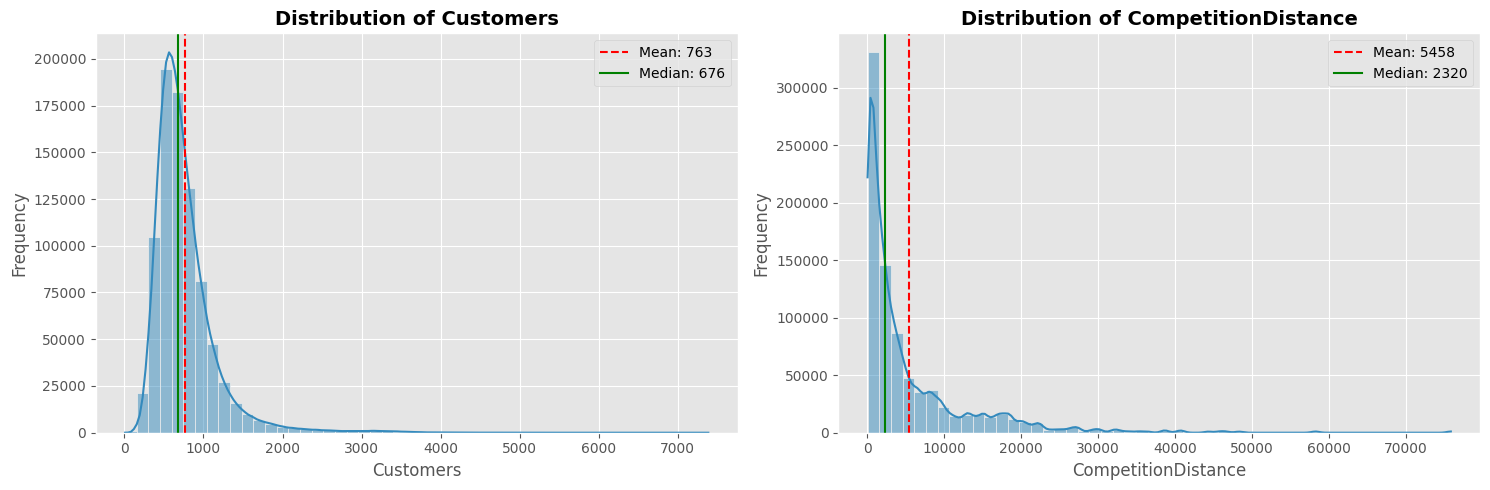

In [26]:
print("UNIVARIATE ANALYSIS: Numerical Variables")

num_vars = ['Customers', 'CompetitionDistance']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_plot = df_master.reset_index()

for i, var in enumerate(num_vars):
    sns.histplot(data=df_plot, x=var, bins=50, kde=True, ax=axes[i], color='#348ABD')
    axes[i].set_title(f'Distribution of {var}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    
    # Mean and median
    mean_val = df_plot[var].mean()
    median_val = df_plot[var].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.0f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.0f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

As we can see, there is a day where there were ~7400 customers and this leads to a right-skewed distribution. The same with competition distance, as we can see that there are a lot of close competitors but few further away ones which make the right tail of the distribution longer.

UNIVARIATE ANALYSIS: Categorical & Binary Variables


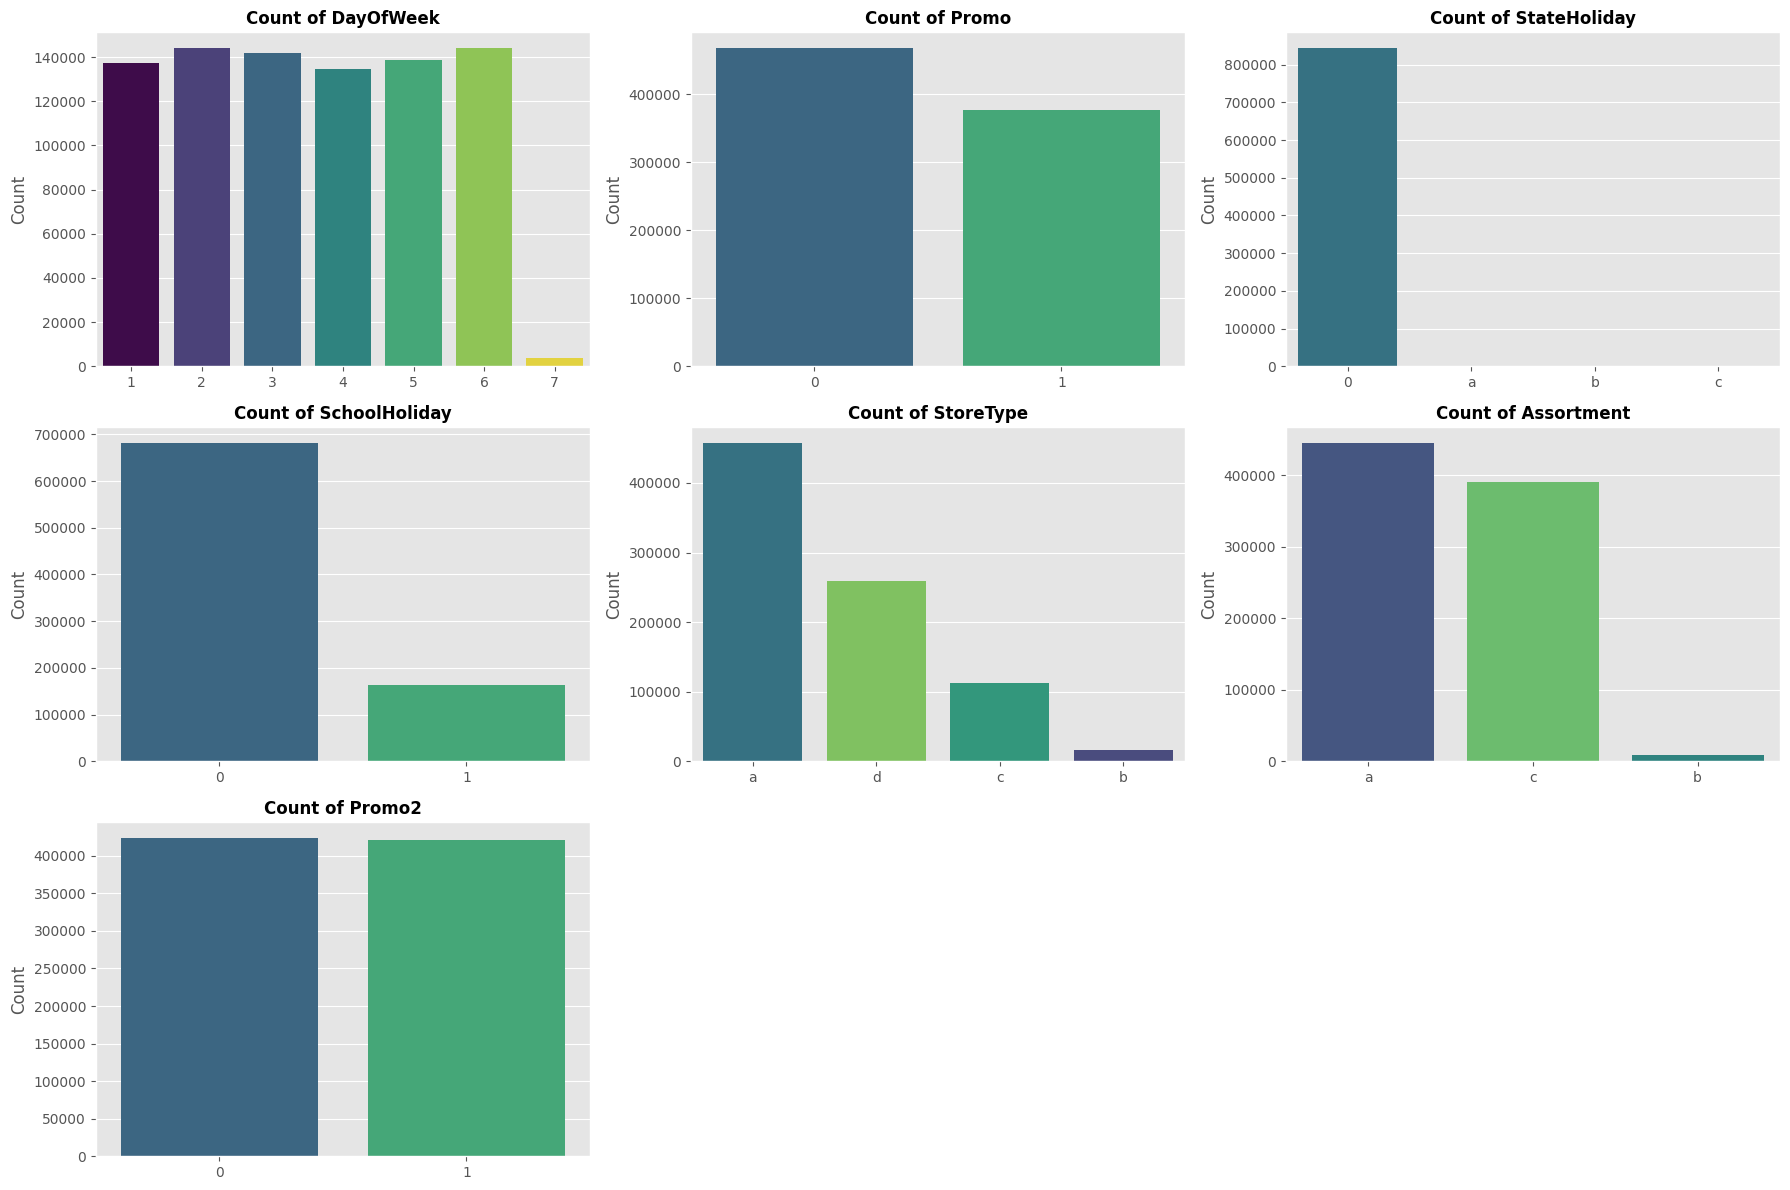

In [27]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

print("UNIVARIATE ANALYSIS: Categorical & Binary Variables")

cat_vars = ['DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'Promo2']

# Calculamos la cuadrícula (ej. 3 filas, 3 columnas)
rows = math.ceil(len(cat_vars) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

for i, var in enumerate(cat_vars):
    # Convertimos a string momentáneamente si es StateHoliday para evitar mezclas de tipos
    if var == 'StateHoliday':
        plot_data = df_master[var].astype(str)
    else:
        plot_data = df_master[var]
    
    # 🔥 LÓGICA DE NEGOCIO: Ordenamos DayOfWeek de 1 a 7. El resto, por volumen.
    if var == 'DayOfWeek':
        plot_order = sorted(plot_data.unique())
    else:
        plot_order = plot_data.value_counts().index
        
    # 🔥 FIX SEABORN WARNING: Añadimos hue=plot_data y legend=False
    sns.countplot(
        x=plot_data, 
        ax=axes[i], 
        palette='viridis', 
        order=plot_order,
        hue=plot_data,
        legend=False
    )
    
    axes[i].set_title(f'Count of {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Ocultamos los subgráficos sobrantes si la cuadrícula es más grande que las variables
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

As we can see, the distribution of weekday is more or less uniform (not in Sundays).

Also, stores tend to have promotions active (Promo and Promo2, being Promo2 more popular).

The days, as we have seen previously, are Non holidays in state.

There is a good proportion of school holiday days.

Predominant Store type is a, followed by d, c and b. 

Assorment a and c are the most common, while b is nearly inexistent.


### Bivariate Analysis

BIVARIATE ANALYSIS: Categorical & Binary drivers vs Sales


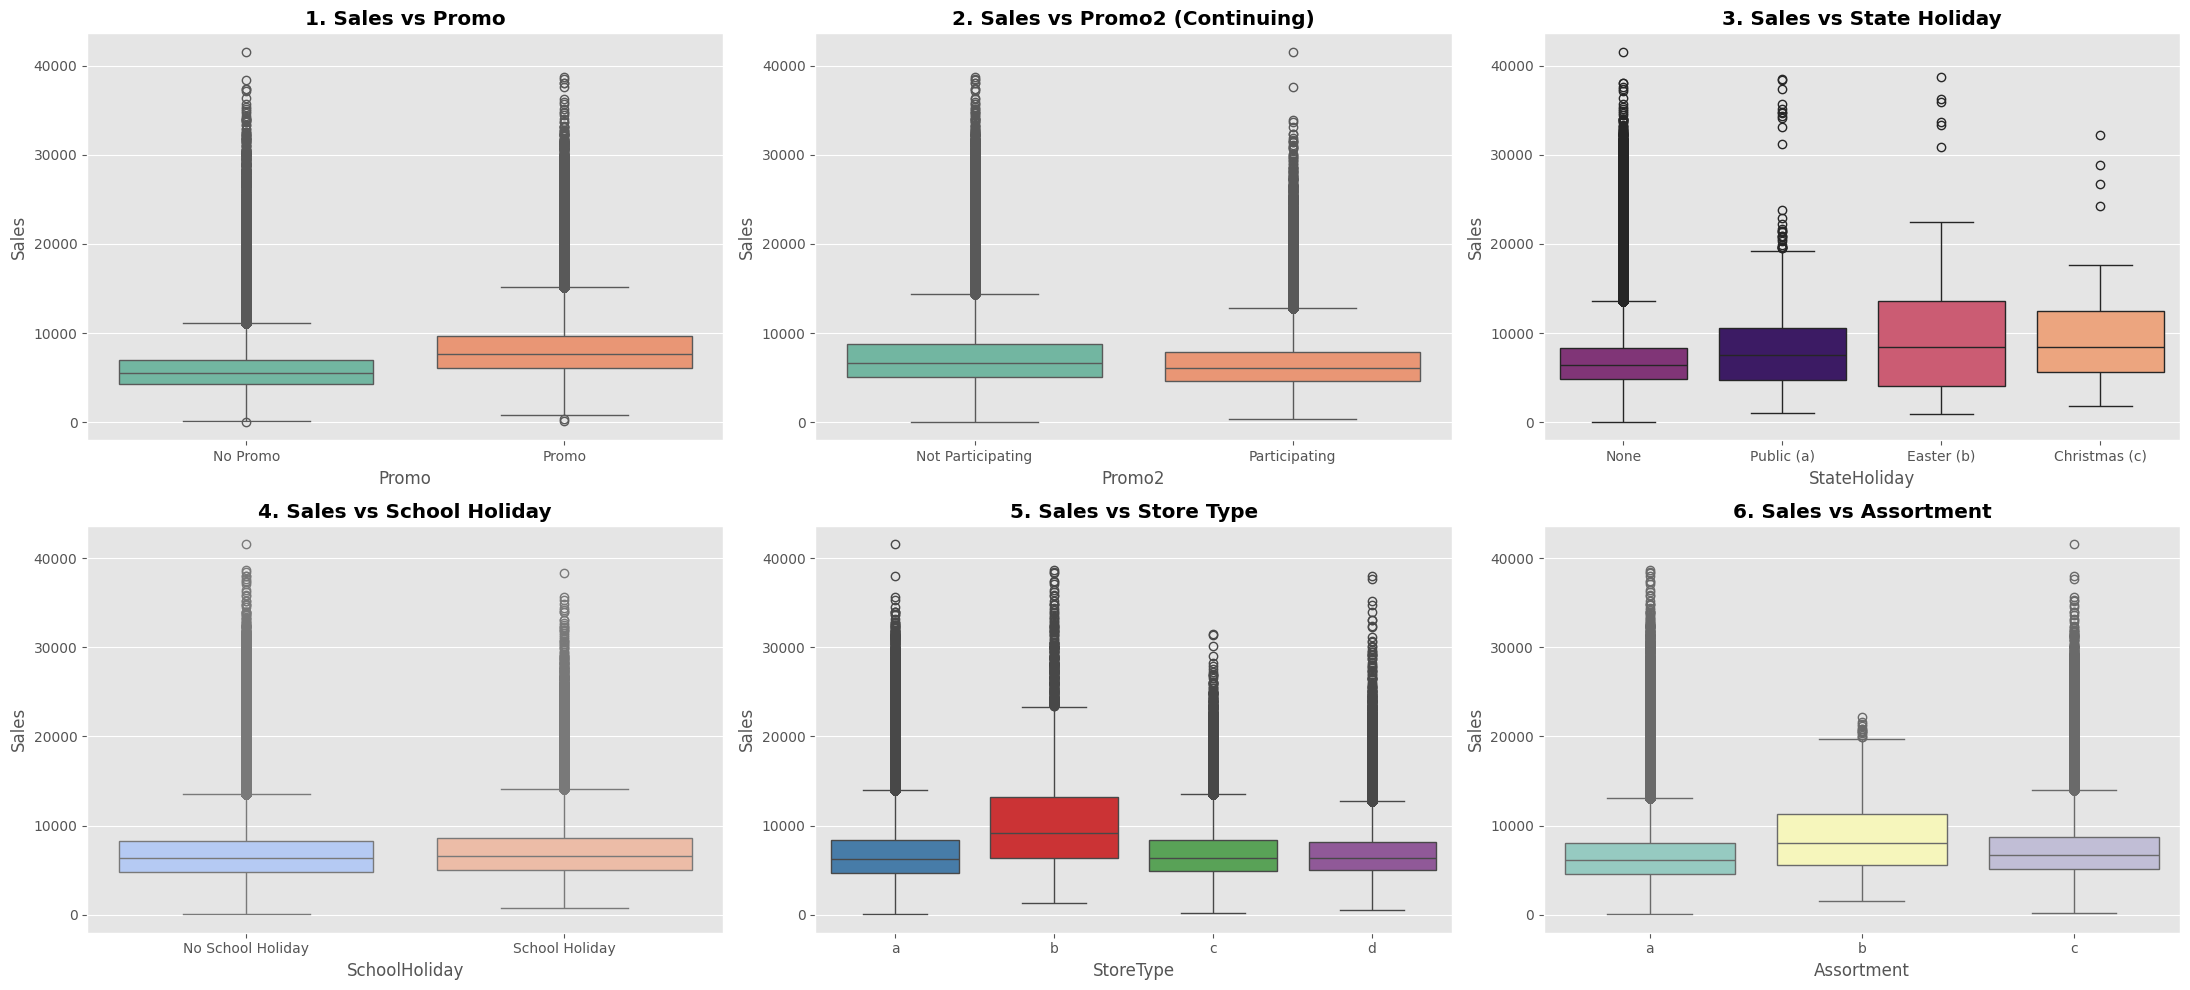

In [28]:
print("BIVARIATE ANALYSIS: Categorical & Binary drivers vs Sales")

# Preparamos los datos (reseteando índice y filtrando días abiertos)
df_biv = df_master.reset_index()

# Convertimos StateHoliday a string por si acaso
df_biv['StateHoliday'] = df_biv['StateHoliday'].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

# 1. Ventas vs Promo
sns.boxplot(data=df_biv, x='Promo', y='Sales', palette='Set2', ax=axes[0, 0], hue='Promo', legend=False)
axes[0, 0].set_title('1. Sales vs Promo', fontweight='bold')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['No Promo', 'Promo'])

# 2. Ventas vs Promo2
sns.boxplot(data=df_biv, x='Promo2', y='Sales', palette='Set2', ax=axes[0, 1], hue='Promo2', legend=False)
axes[0, 1].set_title('2. Sales vs Promo2 (Continuing)', fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Not Participating', 'Participating'])

# 3. Ventas vs StateHoliday
sns.boxplot(data=df_biv, x='StateHoliday', y='Sales', palette='magma', order=['0', 'a', 'b', 'c'], ax=axes[0, 2], hue='StateHoliday', legend=False)
axes[0, 2].set_title('3. Sales vs State Holiday', fontweight='bold')
axes[0, 2].set_xticks([0, 1, 2, 3])
axes[0, 2].set_xticklabels(['None', 'Public (a)', 'Easter (b)', 'Christmas (c)'])

# 4. Ventas vs SchoolHoliday
sns.boxplot(data=df_biv, x='SchoolHoliday', y='Sales', palette='coolwarm', ax=axes[1, 0], hue='SchoolHoliday', legend=False)
axes[1, 0].set_title('4. Sales vs School Holiday', fontweight='bold')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['No School Holiday', 'School Holiday'])

# 5. Ventas vs StoreType
sns.boxplot(data=df_biv, x='StoreType', y='Sales', palette='Set1', order=['a', 'b', 'c', 'd'], ax=axes[1, 1], hue='StoreType', legend=False)
axes[1, 1].set_title('5. Sales vs Store Type', fontweight='bold')

# 6. Ventas vs Assortment
sns.boxplot(data=df_biv, x='Assortment', y='Sales', palette='Set3', order=['a', 'b', 'c'], ax=axes[1, 2], hue='Assortment', legend=False)
axes[1, 2].set_title('6. Sales vs Assortment', fontweight='bold')

plt.tight_layout()
plt.show()

As we can see, the stores with **Promo** make more sales than those who not, but the ones in **Promo2** are not improving those who are not participating. This can be explained with the Selection Bias theory. Rossmann does not put Promo2 to stores that are making good sales, as they are already losing money with Promo. They select those stores that need promos in order to stimulate demand. That is why their sales are lower.

<br>

Being in a **holiday** results in more sales, as we can see in the 3 graph. Easter is the time of the year with better median in relation to sales.
However, if there is a **school holiday** is not as much significant.

<br>

Surprisingly, the store type "b" is the one with more sales! It is shocking as it is the less common store type in our data.
Same happens with assortment! The less common type of assortment is the one that reports more sales.

These stores are pretty rare, but they are the lead in sales. Why? Because they are the "Flagship Stores" or the ones inside big airports or train stations. They are opened 24/7, sell everything (Assortment: b-extra) and have the better sales.

In [29]:
print("CONTINGENCY TABLE: StoreType vs Assortment")
# Usamos df_store porque solo queremos contar cuántos edificios hay de cada tipo, no las ventas diarias
display(pd.crosstab(df_store['StoreType'], df_store['Assortment'], margins=True, margins_name='Total'))

CONTINGENCY TABLE: StoreType vs Assortment


Assortment,a,b,c,Total
StoreType,,,,
a,381,0,221,602
b,7,9,1,17
c,77,0,71,148
d,128,0,220,348
Total,593,9,513,1115


> NOTA:Falta por analizar: Closer competence

BIVARIATE ANALYSIS: Competition Distance vs Sales


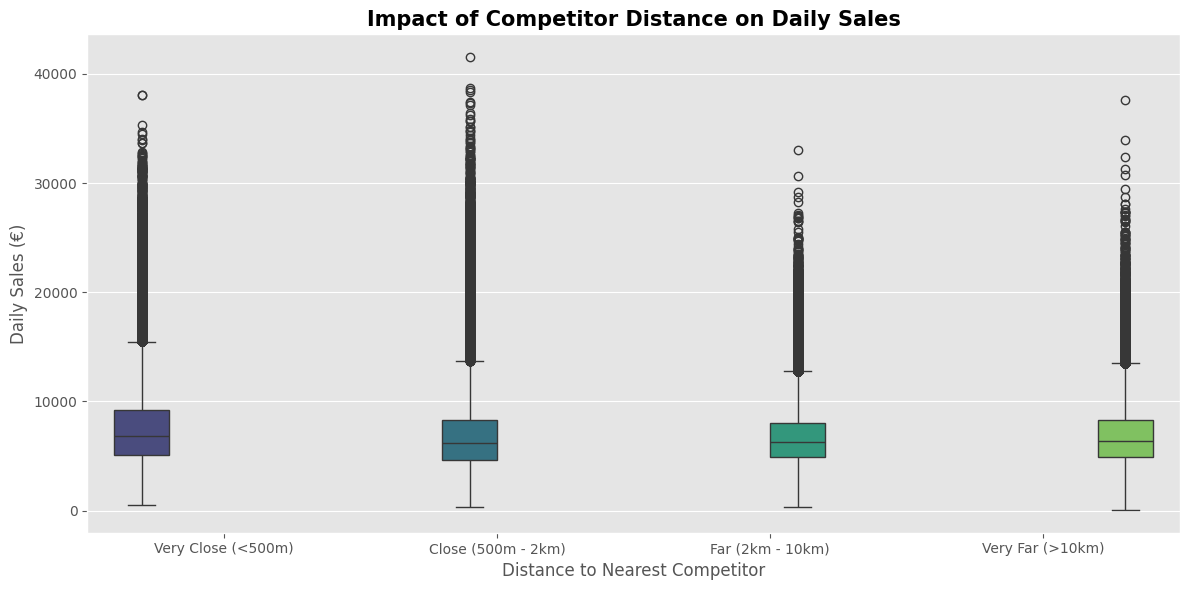


Sales median by group of Distances to Competition:


,Sales
CompDistance_Bin,
Very Close (<500m),6791.0
Close (500m - 2km),6207.0
Far (2km - 10km),6289.0
Very Far (>10km),6378.0


In [35]:
print("BIVARIATE ANALYSIS: Competition Distance vs Sales")

# Filtramos solo los días abiertos
df_eda_comp = df_master.reset_index().copy()

# 1. Definimos los cortes (bins) y las etiquetas
bins = [0, 500, 2000, 10000, df_eda_comp['CompetitionDistance'].max()]
labels = ['Very Close (<500m)', 'Close (500m - 2km)', 'Far (2km - 10km)', 'Very Far (>10km)']

# 2. Creamos la columna discretizada usando pd.cut
df_eda_comp['CompDistance_Bin'] = pd.cut(df_eda_comp['CompetitionDistance'], 
                                         bins=bins, 
                                         labels=labels, 
                                         include_lowest=True)

# 3. Gráfico (Boxplot para ver la mediana y la dispersión)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda_comp, x='CompDistance_Bin', y='Sales', palette='viridis', hue='CompDistance_Bin', legend=False)

plt.title('Impact of Competitor Distance on Daily Sales', fontsize=15, fontweight='bold')
plt.xlabel('Distance to Nearest Competitor', fontsize=12)
plt.ylabel('Daily Sales (€)', fontsize=12)

plt.tight_layout()
plt.show()

# Extra: Vemos los números exactos de la mediana
print("\nSales median by group of Distances to Competition:")
display(df_eda_comp.groupby('CompDistance_Bin')['Sales'].median().to_frame())

We performed a binning analysis on `CompetitionDistance` to understand its impact on daily sales. Counterintuitively, stores with competitors **Very Close (<500m)** do not show a significant drop in median sales compared to those with competitors further away. 

In retail, extreme proximity to a competitor often indicates a highly commercial location (e.g., city centers, shopping malls) with massive foot traffic. The sheer volume of potential customers in these prime locations heavily outweighs the negative effect of market cannibalization.

THE MONOPOLY EFFECT & TIME SERIES SEASONALITY (Updated)


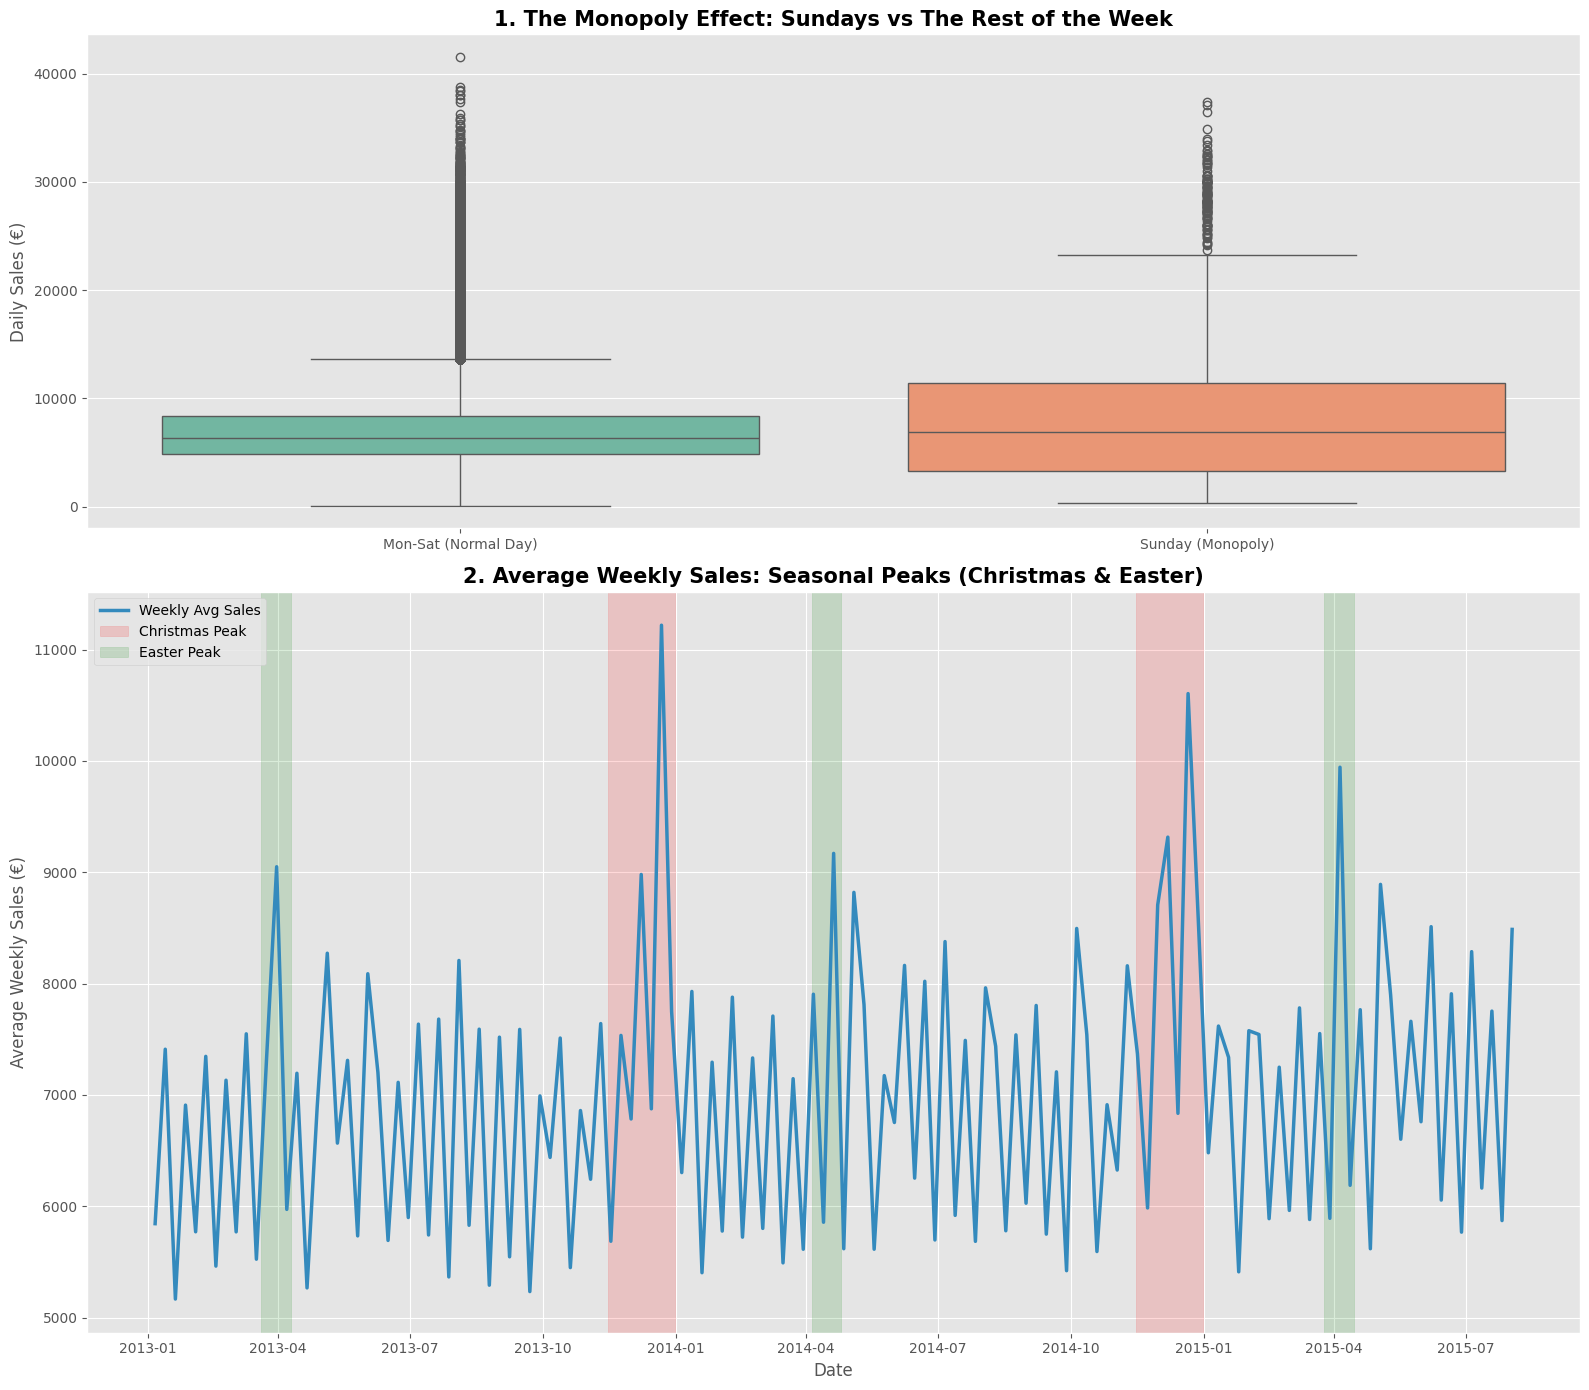

In [30]:
print("THE MONOPOLY EFFECT & TIME SERIES SEASONALITY (Updated)")

# Aseguramos que trabajamos con una copia limpia
df_open = df_master.copy()
df_open['Is_Sunday'] = df_open['DayOfWeek'].apply(lambda x: 'Sunday (Monopoly)' if x == 7 else 'Mon-Sat (Normal Day)')

fig, axes = plt.subplots(2, 1, figsize=(16, 14), gridspec_kw={"height_ratios": (.4, .6)})

# --- Gráfico 1: El Efecto Monopolio ---
sns.boxplot(data=df_open, x='Is_Sunday', y='Sales', palette='Set2', ax=axes[0], hue='Is_Sunday', legend=False)
axes[0].set_title('1. The Monopoly Effect: Sundays vs The Rest of the Week', fontsize=15, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Daily Sales (€)')

# --- Gráfico 2: Estacionalidad Anual ---
# Agrupamos por SEMANA ('W') para suavizar la línea y detectar patrones
weekly_sales = df_open['Sales'].resample('W').mean()

axes[1].plot(weekly_sales.index, weekly_sales.values, color='#348ABD', linewidth=2.5, label='Weekly Avg Sales')
axes[1].set_title('2. Average Weekly Sales: Seasonal Peaks (Christmas & Easter)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Average Weekly Sales (€)')
axes[1].set_xlabel('Date')

# --- Sombreado de Temporadas ---

# Navidad (Rojo)
axes[1].axvspan('2013-11-15', '2013-12-31', color='red', alpha=0.15, label='Christmas Peak')
axes[1].axvspan('2014-11-15', '2014-12-31', color='red', alpha=0.15)

# Semana Santa / Easter (Verde) - Fechas aproximadas de picos en el dataset
axes[1].axvspan('2013-03-20', '2013-04-10', color='green', alpha=0.15, label='Easter Peak')
axes[1].axvspan('2014-04-05', '2014-04-25', color='green', alpha=0.15)
axes[1].axvspan('2015-03-25', '2015-04-15', color='green', alpha=0.15)

axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

**Seasonality & Monopoly Insights:**
* **Monopoly Effect:** Stores that remain open on Sundays (mostly Type 'b') show a massive sales spike, as they capture the market demand while competitors are legally required to close.
* **Annual Cycles:** Sales are not static. We observe clear recurrent peaks during **Christmas** (the highest of the year) and **Easter**. This confirms that the model must include temporal features (Month, Week of Year) to capture these cyclical revenue drivers.
* **Variable Correlation:** Cross-tabulation confirmed that `Assortment b` exists exclusively within `StoreType b`, indicating these represent high-traffic flagship locations.

> **NOTE**: the fact that in the previous boxplot, we have seen that easter is the best period for our stores is not shown in this temporal graph. That is because Rossmann marks Christmas as only 25 and 26 of december more or less and Easter the whole week, that is why the distribution shown in the previous graph is a bit misinformative.

## Final Veredict (EDA)

After a deep dive into the Rossmann Store Sales dataset, we have extracted the following key business and statistical pillars that will guide our Feature Engineering and Modeling phases:

### 1. Sales Distribution & The "Outlier" Paradox

* **Right-Skewed Nature:** Daily sales follow a right-skewed distribution. While statistical methods (Boxplots) flag sales above **15,000€** as outliers, they are **legitimate high-demand events** (Promos, Christmas).
* **Modeling Decision:** We will **not** remove these peaks. A Time Series model must learn to predict these high-revenue days to be useful for inventory management.

### 2. The Drivers of Performance: Promos & Store Types

* **Promo vs. Promo2:** While standard `Promo` significantly boosts sales, `Promo2` shows lower median sales. This is a classic case of **Selection Bias**: Rossmann likely implements the permanent `Promo2` in underperforming or rural stores to stimulate stagnant demand, whereas high-performing stores don't need the extra margin sacrifice.
* **The "Flagship" Effect (Type 'b'):** Although **Store Type 'b'** and **Assortment 'b'** are the rarest in the dataset, they are the top performers. These represent "Flagship Stores" located in high-traffic hubs (airports/train stations).

### 3. Temporal Dynamics & Seasonality

* **The Monopoly Effect:** Sunday sales are significantly higher for the few stores allowed to open. This "Monopoly" status absorbs all regional demand when competitors are legally required to close.
* **Seasonality Correction:** Our Time Series analysis reveals massive peaks during **Christmas** and **Easter**.
* *Note on Data Labeling:* In categorical plots, Easter might show a higher median than Christmas because `StateHoliday` only marks Dec 25th/26th (when stores are closed), while the actual "Christmas Peak" occurs in the days leading up to it (marked as "Regular Days").



### 4. Key Takeaways for Feature Engineering

* **Collinearity:** `Assortment b` is exclusively tied to `StoreType b`. We must be aware of this redundancy.
* **Granular Time Features:** Since the "Holiday Effect" often happens *before* the actual holiday, we need to extract `WeekOfYear`, `Month`, and `Day` to capture the buildup of sales.
* **Competition Impact:** Distance to competition is highly skewed; we should explore how the "age" of a competitor (how long they've been open) affects our store's maturity.